In [1]:
import json                                                                                                                                                                                                                                          
import random
from pathlib import Path

%matplotlib inline
import matplotlib.patches as patches
import matplotlib.pyplot as plt                                                                                                                                                                                                                      
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image                                                                                                                                                                                                                                
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection import MeanAveragePrecision                                                                                                                                                                                              

In [2]:
# Manual Seed for Reproducibility
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)                                                                                                                                                                                                               
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT = Path("26045171/Object_Detection/coco")
RUNS_DIR     = Path("runs/exp3_fasterrcnn_v2")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# torchvision reserves class index 0 for background, so our 5 lettuce                                                                                                                                                                                
# classes map to indices 1–5, which conveniently matches COCO's 1-indexed IDs.
CLASS_NAMES = ["__background__", "Ready", "empty_pod", "germination", "pod", "young"]                                                                                                                                                                
NUM_CLASSES = len(CLASS_NAMES)  # 6
                                                                                                                                                                                                                                                   
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 6


In [3]:
class LettuceDataset(Dataset):
    def __init__(self, img_dir, ann_file):                                                                                                                                                                                            
        self.img_dir = Path(img_dir)

        with open(ann_file) as f:                                                                                                                                                                                                                    
            coco = json.load(f)
                                                                                                                                                                                                                                       
        # Create image_id to annotations dictionary for efficient lookup in __getitem__
        self.ann_by_img = {}
        for ann in coco["annotations"]:                                                                                                                                                                                                              
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)

        self.images = []
        self.unannotated_count = 0

        # Keep images that have annotations
        # Report unannotated images for debugging
        for img in coco["images"]:
            if img["id"] in self.ann_by_img:
                self.images.append(img)
            else:
                self.unannotated_count += 1

    def details(self):
        return f"With annotations: {len(self.images):<4} | Unannotated: {self.unannotated_count:<4}"

    def __len__(self):                                                                                                                                                                                                                               
        return len(self.images)

    def __getitem__(self, idx):
        img_metadata = self.images[idx]
        img  = Image.open(self.img_dir / img_metadata["file_name"]).convert("RGB")                                                                                                                                                                           
                                                                                                                                                                                                                 
        boxes, labels = [], []
        for ann in self.ann_by_img[img_metadata["id"]]:                                                                                                                                                                                                      
            x, y, w, h = ann["bbox"]

            if w <= 0 or h <= 0 or ann["category_id"] not in range(1, NUM_CLASSES):                                                                                                                                                                                                                     
                continue  # skip malformed annotations and invalid category IDs

            # Convert COCO [x, y, w, h] to [x1, y1, x2, y2]                                                                                                                                                                                           
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

        target = {                                                                                                                                                                                                                                   
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),                                                                                                                                                                                
            "labels":   torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_metadata["id"]]),                                                                                                                                                                                                  
        }

        img = TF.to_tensor(img)
   
        return img, target

In [4]:
def collate_fn(batch):                                                                                                                                                                                                                               
    return tuple(zip(*batch))                                                                                                                                                                                                                        

train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")                                                                                                                                                                                                              
val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")                                                                                                                                                                         
test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)

print(f"TRAIN:      | {train_ds.details()}")
print(f"VALIDATION: | {val_ds.details()}")
print(f"TEST:       | {test_ds.details()}")

TRAIN:      | With annotations: 1050 | Unannotated: 7   
VALIDATION: | With annotations: 224  | Unannotated: 2   
TEST:       | With annotations: 226  | Unannotated: 0   


In [5]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_faster_rcnn(num_classes):
    # Load Faster-RCNN with a ResNet-50 + FPN backbone pretrained on COCO.
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT                                                                                                                                                                           
    model = fasterrcnn_resnet50_fpn(weights=weights)                                                                                                                                                                                           

    # Get the number of input features for the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # The pretrained head predicts 91 COCO classes.
    # We replace it with a new one for our 6 classes.                                                                                                                                                                            
    # The backbone weights are kept and will be fine-tuned on our data.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)                                                                                                                                                                      
                                                                                                                                                                                                                           
    return model

model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    total_images = 0

    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(images)
        total_images += len(images)

    return running_loss / total_images # Calculate mean instance loss over the epoch

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        filtered = []
        for pred in preds:
            keep = pred["scores"] > 0.05 # Filter out predictions with low confidence scores
            filtered.append({
                "boxes":  pred["boxes"][keep],
                "labels": pred["labels"][keep],
                "scores": pred["scores"][keep],
            })

        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in filtered],  # score-filtered model outputs
            [{k: v.cpu() for k, v in t.items()} for t in targets],   # ground-truth boxes & labels
        )
    return metric.compute()

In [ ]:
@torch.no_grad()
def compute_val_loss(model, loader):
    model.train()  # training mode so the model returns a loss dict instead of predictions
    total_loss   = 0.0
    total_images = 0

    for images, targets in loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total_loss   += sum(loss_dict.values()).item() * len(images)
        total_images += len(images)

    return total_loss / total_images # Calculate mean instance loss over the epoch

In [9]:
optimizer = torch.optim.SGD(
    model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map       = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_map": []}

for epoch in range(1, EPOCHS + 1):
    train_loss  = train_one_epoch(model, train_loader, optimizer)
    val_loss    = compute_val_loss(model, val_loader)
    val_metrics = evaluate(model, val_loader)

    val_map = val_metrics["map"].item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_map"].append(val_map)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50-95={val_map:.4f}")

    if val_map > best_map:
        best_map = val_map
        patience_counter = 0
        torch.save(model.state_dict(), RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50-95={best_map:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break


Epoch   1/300  loss=1.3872/0.9339  mAP@50=0.5010/0.5047
  → Best saved (mAP@50=0.5047)
Epoch   2/300  loss=0.8132/0.6862  mAP@50=0.7023/0.7008
  → Best saved (mAP@50=0.7008)
Epoch   3/300  loss=0.6466/0.5963  mAP@50=0.7955/0.7996
  → Best saved (mAP@50=0.7996)
Epoch   4/300  loss=0.5737/0.5404  mAP@50=0.8580/0.8557
  → Best saved (mAP@50=0.8557)
Epoch   5/300  loss=0.5304/0.5137  mAP@50=0.8911/0.8873
  → Best saved (mAP@50=0.8873)
Epoch   6/300  loss=0.4982/0.5007  mAP@50=0.8985/0.8895
  → Best saved (mAP@50=0.8895)
Epoch   7/300  loss=0.4793/0.4815  mAP@50=0.9159/0.9015
  → Best saved (mAP@50=0.9015)
Epoch   8/300  loss=0.4615/0.4715  mAP@50=0.9244/0.9043
  → Best saved (mAP@50=0.9043)
Epoch   9/300  loss=0.4465/0.4669  mAP@50=0.9327/0.9118
  → Best saved (mAP@50=0.9118)
Epoch  10/300  loss=0.4312/0.4632  mAP@50=0.9396/0.9156
  → Best saved (mAP@50=0.9156)
Epoch  11/300  loss=0.4185/0.4512  mAP@50=0.9419/0.9135
Epoch  12/300  loss=0.4090/0.4482  mAP@50=0.9448/0.9153
Epoch  13/300  los

In [10]:
# Reload the best checkpoint (not the last epoch) to report final numbers
model.load_state_dict(torch.load(RUNS_DIR / "best.pth", map_location=DEVICE))
test_metrics = evaluate(model, test_loader)

print("=== TEST SET RESULTS ===")
print(f"mAP@50:    {test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {test_metrics['map'].item():.4f}")
print(f"Recall:    {test_metrics['mar_100'].item():.4f}")

print("\nPer-class AP@50-95:")
for name, ap in zip(CLASS_NAMES[1:], test_metrics["map_per_class"]):
    print(f"  {name:15s}: {ap:.4f}")

=== TEST SET RESULTS ===
mAP@50:    0.9364
mAP@50-95: 0.6561
Recall:    0.7422

Per-class AP@50:
  Ready          : 0.4619
  empty_pod      : 0.7158
  germination    : 0.7261
  pod            : 0.7410
  young          : 0.6358


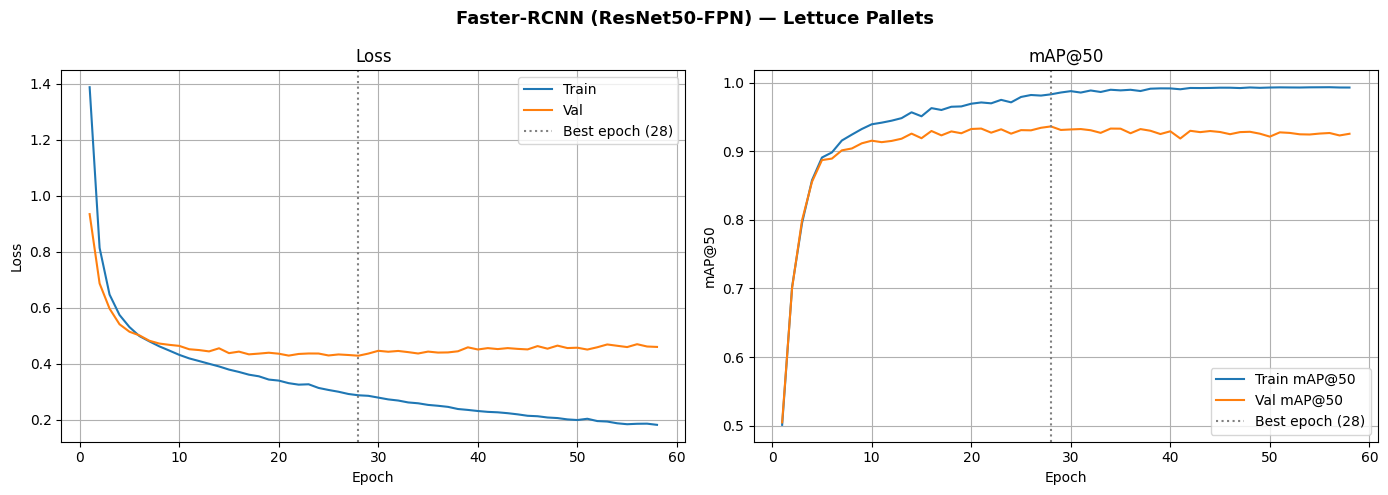

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmax(history["val_map"])) + 1

ax1.plot(epochs_x, history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, history["val_map"], label="Val mAP@50-95", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50-95", title="Validation mAP@50-95")
ax2.legend()
ax2.grid(True)

plt.suptitle("Faster-RCNN (ResNet50-FPN) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

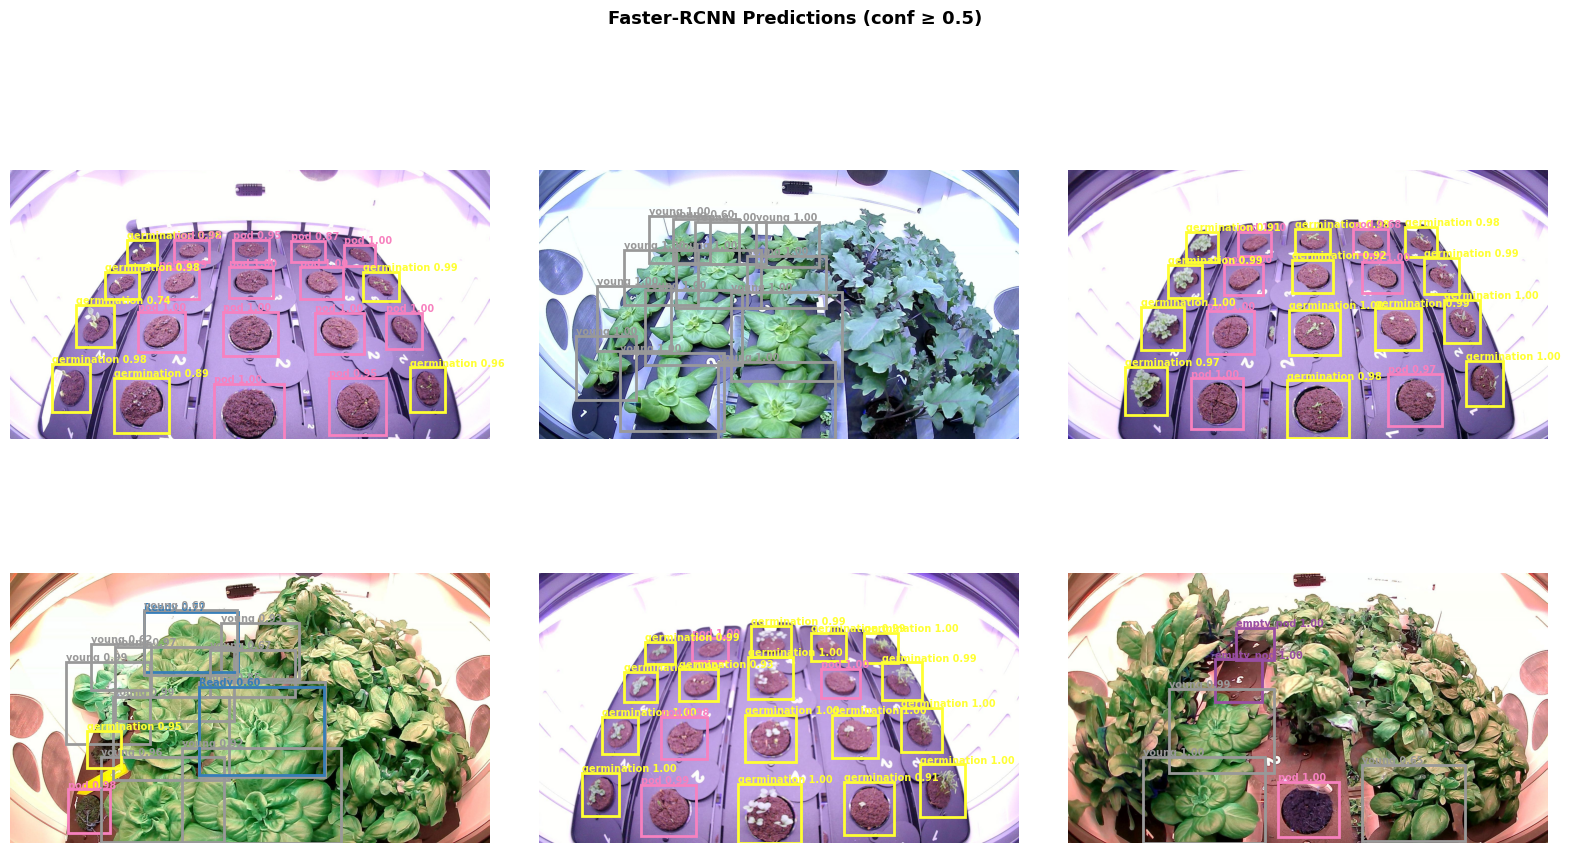

In [13]:
@torch.no_grad()
def plot_predictions(model, dataset, n=6, conf=0.5, seed=STUDENT_ID):                                                                                                                                                                                
    model.eval()                                                                                                                                                                                                                                     
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n)                                                                                                                                                                                                  
    colors  = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))                                                                                                                                                                                            
                                                                                                                                                                                                                                                   
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))                                                                                                                                                                                                 
    for ax, idx in zip(axes.flatten(), indices):                                                                                                                                                                                                     
        img_tensor, _ = dataset[idx]                                                                                                                                                                                                                 
        pred = model([img_tensor.to(DEVICE)])[0]
                                                                                                                                                                                                                                                   
        ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):                                                                                                                                                                 
            if score < conf:                                                                                                                                                                                                                         
                continue
            x1, y1, x2, y2 = box.cpu().tolist()                                                                                                                                                                                                      
            cls = label.item()                                                                                                                                                                                                                       
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,                                                                                                                                                                                                          
                linewidth=2, edgecolor=colors[cls], facecolor="none"
            ))                                                                                                                                                                                                                                       
            ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls]} {score:.2f}",
                    color=colors[cls], fontsize=7, fontweight="bold")
        ax.axis("off")

    plt.suptitle(f"Faster-RCNN Predictions (conf ≥ {conf})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "predictions.png", dpi=150)
    plt.show()

plot_predictions(model, test_ds)

In [14]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead

# All constants (CLASS_NAMES, NUM_CLASSES, DEVICE, STUDENT_ID) are shared
# with Exp 3 — reuse them from the earlier cells.

SSD_RUNS_DIR = Path("runs/exp4_ssd_v2")
SSD_RUNS_DIR.mkdir(parents=True, exist_ok=True)

def build_ssd(num_classes):
    # SSD300 pretrained on COCO 2017 — same pretraining dataset as Faster-RCNN,
    # making the comparison fair in terms of prior knowledge given to each model.
    weights = SSD300_VGG16_Weights.DEFAULT
    model   = ssd300_vgg16(weights=weights)

    # Replace only the classification head for our number of classes.
    # The backbone and box regression head keep their COCO pretrained weights.
    in_channels = [c.in_channels for c in model.head.classification_head.module_list]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes
    )

    return model

ssd_model = build_ssd(NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in ssd_model.parameters())
trainable = sum(p.numel() for p in ssd_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Total params:     24,280,556
Trainable params: 24,241,836


In [15]:
# Same dataset class as Faster-RCNN — no manual resizing needed since SSD300
# resizes all images internally to 300×300 via GeneralizedRCNNTransform.
# Batch=64 is justified by SSD's fixed small input (300×300 vs Faster-RCNN's
# ~800×1333) — the smaller resolution fits more images in GPU memory.
# Faster-RCNN at batch=4 and SSD at batch=64 are each at their practical
# optimum; the different batch sizes do not make the comparison unfair.

ssd_train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json")
ssd_val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")
ssd_test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")

ssd_train_loader = DataLoader(ssd_train_ds, batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_val_loader   = DataLoader(ssd_val_ds,   batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)
ssd_test_loader  = DataLoader(ssd_test_ds,  batch_size=64, collate_fn=collate_fn, num_workers=8, pin_memory=True)

In [16]:
ssd_optimizer = torch.optim.SGD(
    ssd_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)

EPOCHS   = 300
PATIENCE = 30

best_map       = 0.0
patience_counter = 0
ssd_history = {"train_loss": [], "val_loss": [], "val_map": []}

for epoch in range(1, EPOCHS + 1):
    train_loss  = train_one_epoch(ssd_model, ssd_train_loader, ssd_optimizer)
    val_loss    = compute_val_loss(ssd_model, ssd_val_loader)
    val_metrics = evaluate(ssd_model, ssd_val_loader)

    val_map = val_metrics["map"].item()

    ssd_history["train_loss"].append(train_loss)
    ssd_history["val_loss"].append(val_loss)
    ssd_history["val_map"].append(val_map)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"mAP@50-95={val_map:.4f}")

    if val_map > best_map:
        best_map = val_map
        patience_counter = 0
        torch.save(ssd_model.state_dict(), SSD_RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50-95={best_map:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch   1/300  loss=9.1848/7.3807  mAP@50=0.0330/0.0351
  → Best saved (mAP@50=0.0351)
Epoch   2/300  loss=6.2471/5.0758  mAP@50=0.1637/0.1736
  → Best saved (mAP@50=0.1736)
Epoch   3/300  loss=4.4981/4.0448  mAP@50=0.2768/0.2772
  → Best saved (mAP@50=0.2772)
Epoch   4/300  loss=3.8392/3.6606  mAP@50=0.3729/0.3698
  → Best saved (mAP@50=0.3698)
Epoch   5/300  loss=3.5373/3.4545  mAP@50=0.4798/0.4670
  → Best saved (mAP@50=0.4670)
Epoch   6/300  loss=3.3400/3.3036  mAP@50=0.5365/0.5228
  → Best saved (mAP@50=0.5228)
Epoch   7/300  loss=3.1943/3.1773  mAP@50=0.5847/0.5688
  → Best saved (mAP@50=0.5688)
Epoch   8/300  loss=3.0805/3.0884  mAP@50=0.6202/0.6064
  → Best saved (mAP@50=0.6064)
Epoch   9/300  loss=2.9497/2.9638  mAP@50=0.6644/0.6488
  → Best saved (mAP@50=0.6488)
Epoch  10/300  loss=2.8293/2.8748  mAP@50=0.6989/0.6790
  → Best saved (mAP@50=0.6790)
Epoch  11/300  loss=2.7492/2.8082  mAP@50=0.7249/0.7017
  → Best saved (mAP@50=0.7017)
Epoch  12/300  loss=2.6819/2.7748  mAP@50=0

In [17]:
ssd_model.load_state_dict(torch.load(SSD_RUNS_DIR / "best.pth", map_location=DEVICE))
ssd_test_metrics = evaluate(ssd_model, ssd_test_loader)

print("=== SSD TEST SET RESULTS ===")
print(f"mAP@50:    {ssd_test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {ssd_test_metrics['map'].item():.4f}")
print(f"Recall:    {ssd_test_metrics['mar_100'].item():.4f}")

print("\nPer-class AP@50-95:")
for name, ap in zip(CLASS_NAMES[1:], ssd_test_metrics["map_per_class"]):
    print(f"  {name:15s}: {ap:.4f}")

=== SSD TEST SET RESULTS ===
mAP@50:    0.9107
mAP@50-95: 0.6134
Recall:    0.7130

Per-class mAP@50-95:
  Ready          : 0.4779
  empty_pod      : 0.6368
  germination    : 0.6697
  pod            : 0.6884
  young          : 0.5941


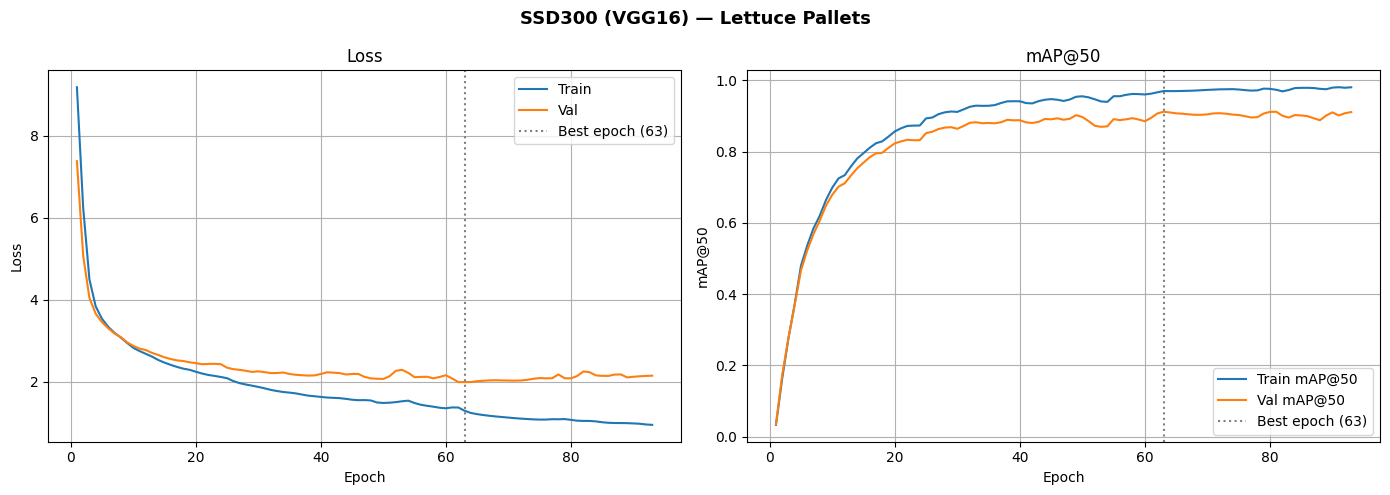

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x   = range(1, len(ssd_history["train_loss"]) + 1)
best_epoch = int(np.argmax(ssd_history["val_map"])) + 1

ax1.plot(epochs_x, ssd_history["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, ssd_history["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_x, ssd_history["val_map"], label="Val mAP@50-95", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle=":", lw=1.5, label=f"Best epoch ({best_epoch})")
ax2.set(xlabel="Epoch", ylabel="mAP@50-95", title="Validation mAP@50-95")
ax2.legend()
ax2.grid(True)

plt.suptitle("SSD300 (VGG16) — Lettuce Pallets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SSD_RUNS_DIR / "training_curves.png", dpi=150)
plt.show()

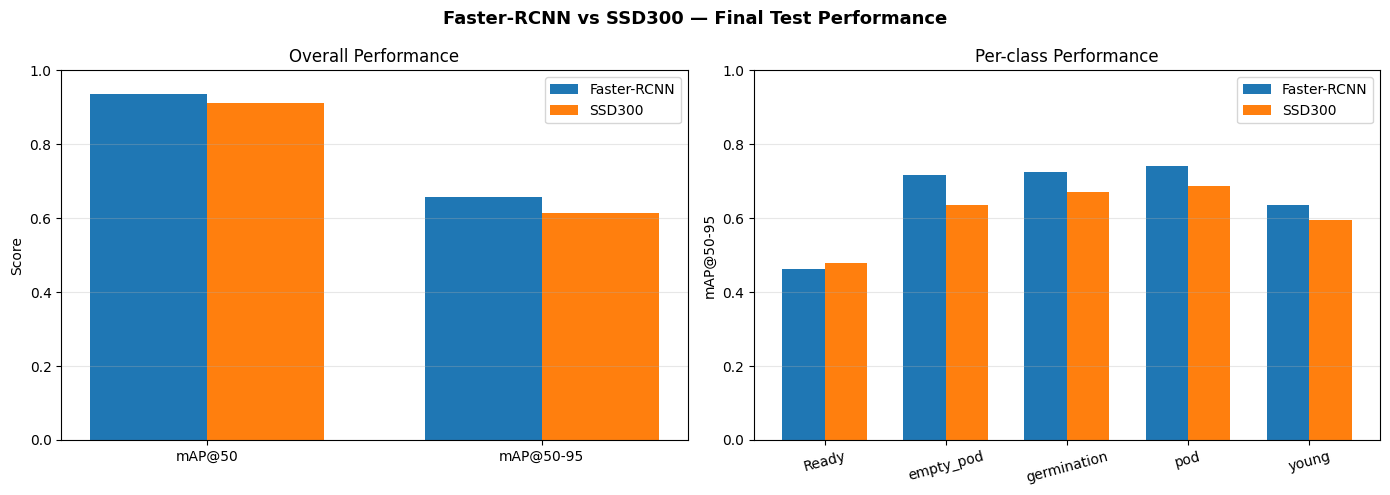

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35

# Overall mAP
metrics_labels = ["mAP@50", "mAP@50-95"]
frcnn_overall  = [test_metrics["map_50"].item(), test_metrics["map"].item()]
ssd_overall    = [ssd_test_metrics["map_50"].item(), ssd_test_metrics["map"].item()]

x = np.arange(len(metrics_labels))
axes[0].bar(x - width/2, frcnn_overall, width, label="Faster-RCNN", color="tab:blue")
axes[0].bar(x + width/2, ssd_overall,   width, label="SSD300",      color="tab:orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Overall Performance")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

# Per-class mAP@50-95
frcnn_per_class = test_metrics["map_per_class"].tolist()
ssd_per_class   = ssd_test_metrics["map_per_class"].tolist()
x = np.arange(len(CLASS_NAMES[1:]))
axes[1].bar(x - width/2, frcnn_per_class, width, label="Faster-RCNN", color="tab:blue")
axes[1].bar(x + width/2, ssd_per_class,   width, label="SSD300",      color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES[1:], rotation=15)
axes[1].set_ylabel("mAP@50-95")
axes[1].set_title("Per-class Performance")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Faster-RCNN vs SSD300 — Final Test Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/comparison.png", dpi=150)
plt.show()

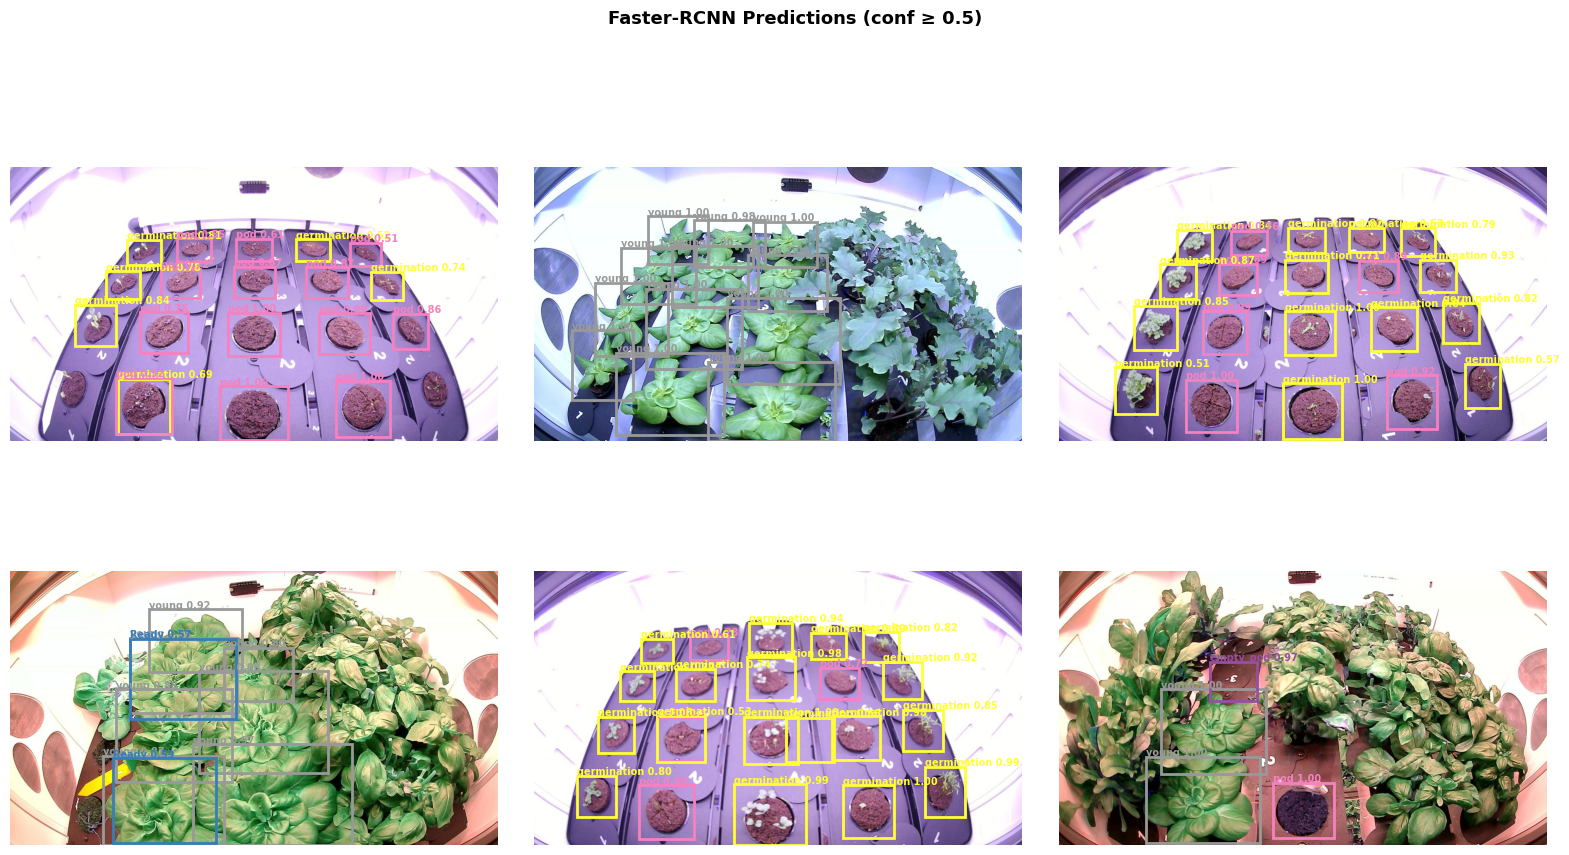

In [20]:
# Identical to Faster-RCNN visualisation — reuses plot_predictions()
plot_predictions(ssd_model, ssd_test_ds)